# Crop Classification and Clustering 7

In [39]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import math

## Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### EDA

In [40]:
df = pd.read_csv('Crop_Recommendation.csv')
df

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


In [41]:
features = df.columns[:-1]
features

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall'],
      dtype='object')

In [42]:
df.Crop.nunique()

22

In [43]:
df.Crop.value_counts()

Crop
Rice           100
Maize          100
Jute           100
Cotton         100
Coconut        100
Papaya         100
Orange         100
Apple          100
Muskmelon      100
Watermelon     100
Grapes         100
Mango          100
Banana         100
Pomegranate    100
Lentil         100
Blackgram      100
MungBean       100
MothBeans      100
PigeonPeas     100
KidneyBeans    100
ChickPea       100
Coffee         100
Name: count, dtype: int64

In [44]:
df.Crop.value_counts(normalize=True)

Crop
Rice           0.045455
Maize          0.045455
Jute           0.045455
Cotton         0.045455
Coconut        0.045455
Papaya         0.045455
Orange         0.045455
Apple          0.045455
Muskmelon      0.045455
Watermelon     0.045455
Grapes         0.045455
Mango          0.045455
Banana         0.045455
Pomegranate    0.045455
Lentil         0.045455
Blackgram      0.045455
MungBean       0.045455
MothBeans      0.045455
PigeonPeas     0.045455
KidneyBeans    0.045455
ChickPea       0.045455
Coffee         0.045455
Name: proportion, dtype: float64

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [46]:
df.isna().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

In [47]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Nitrogen,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
Phosphorus,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
Potassium,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
Temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
Humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
pH_Value,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
Rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


Probably a good idea to standardize these values

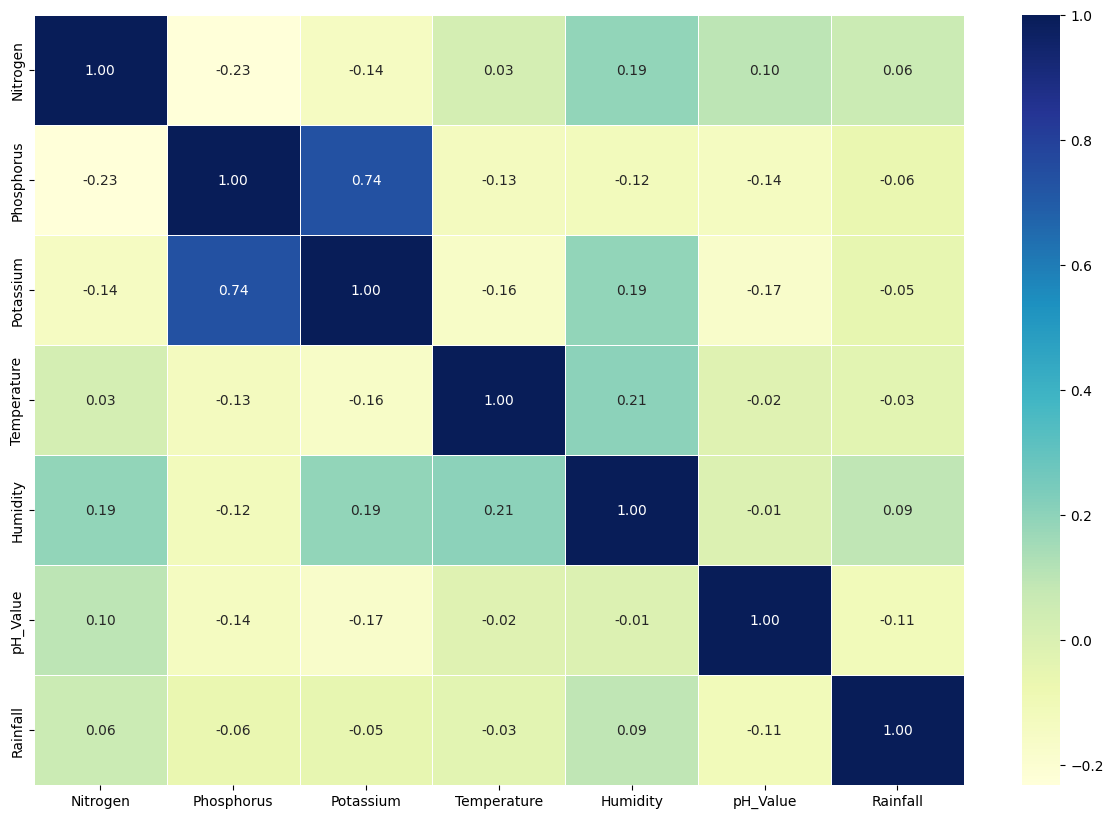

In [49]:
# Correlation Matrix
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            linewidths=0.5, 
            fmt= ".2f", 
            cmap="YlGnBu");

In [52]:
metric_col = df.select_dtypes(include=['number']).columns

<hr>

### Modeling

In [58]:
X = df.drop('Crop', axis=1)
y = df.Crop.values

In [59]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [60]:
# Train and Test Split
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2)

In [61]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1760, 7), (440, 7), (1760,), (440,))

In [62]:
# Put models in a dictionary
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(), 
          "Random Forest": RandomForestClassifier(),
          "GradientBoost": GradientBoostingClassifier(),
          "GaussianNB": GaussianNB(),
          }

In [63]:
# Create function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data
    X_test : testing data
    y_train : labels assosciated with training data
    y_test : labels assosciated with test data
    """
    # Random seed for reproducible results
    np.random.seed(42)
    # Make a list to keep model scores
    model_scores = {}
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [64]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

C:\Users\tuckerd9\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.9568181818181818,
 'Logistic Regression': 0.9636363636363636,
 'Random Forest': 0.9931818181818182,
 'GradientBoost': 0.9818181818181818,
 'GaussianNB': 0.9954545454545455}

I could go with GaussianNB, but just choosing RandomForest model

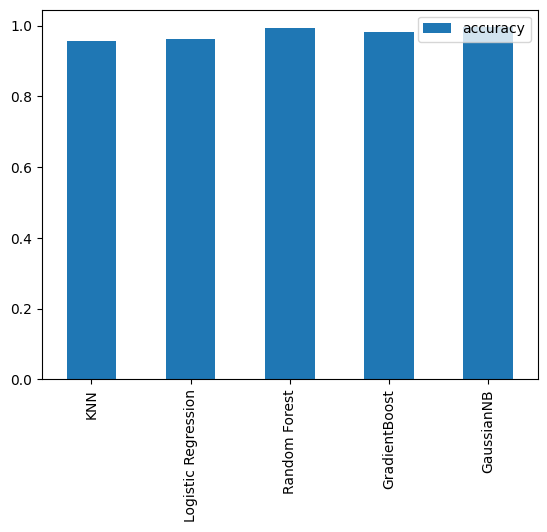

In [65]:
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar();

In [66]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_preds_rf = rf.predict(X_test)

In [67]:
# Create a new dataframe with two columns: 'test' and 'predicted'
df_with_preds = pd.DataFrame({
    'test': y_test,
    'predicted': y_preds_rf
})
df_with_preds

,test,predicted
0,Muskmelon,Muskmelon
1,Watermelon,Watermelon
2,Papaya,Papaya
3,Papaya,Papaya
4,Apple,Apple
...,...,...
435,Rice,Rice
436,Rice,Rice
437,Cotton,Cotton
438,Cotton,Cotton


In [93]:
# Create a new dataframe with the predicted values as a column
df_with_preds = pd.DataFrame(X_test, columns=X_test.columns)
df_with_preds['actual'] = y_test
df_with_preds['predicted'] = y_preds_rf
df_with_preds

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,actual,predicted
1451,101,17,47,29.494014,94.729813,6.185053,26.308209,Muskmelon,Muskmelon
1334,98,8,51,26.179346,86.522581,6.259336,49.430510,Watermelon,Watermelon
1761,59,62,49,43.360515,93.351916,6.941497,114.778071,Papaya,Papaya
1735,44,60,55,34.280461,90.555616,6.825371,98.540477,Papaya,Papaya
1576,30,137,200,22.914300,90.704756,5.603413,118.604465,Apple,Apple
...,...,...,...,...,...,...,...,...,...
59,99,55,35,21.723831,80.238990,6.501698,277.962619,Rice,Rice
71,67,45,38,22.727910,82.170688,7.300411,260.887506,Rice,Rice
1908,121,47,16,23.605640,79.295731,7.723240,72.498009,Cotton,Cotton
1958,116,52,19,22.942767,75.371706,6.114526,67.080226,Cotton,Cotton


In [94]:
def plot_confusion_matrix(y_test, predictions):
    # Plot the confusion matrix
    cf_matrix = confusion_matrix(y_test, predictions)
    fig = plt.subplots(figsize=(10, 8))
    sns.set(font_scale=1.4)
    sns.heatmap(cf_matrix, annot=True, fmt='d')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()
    
    # Reset font scale to default
    sns.set(font_scale=1)

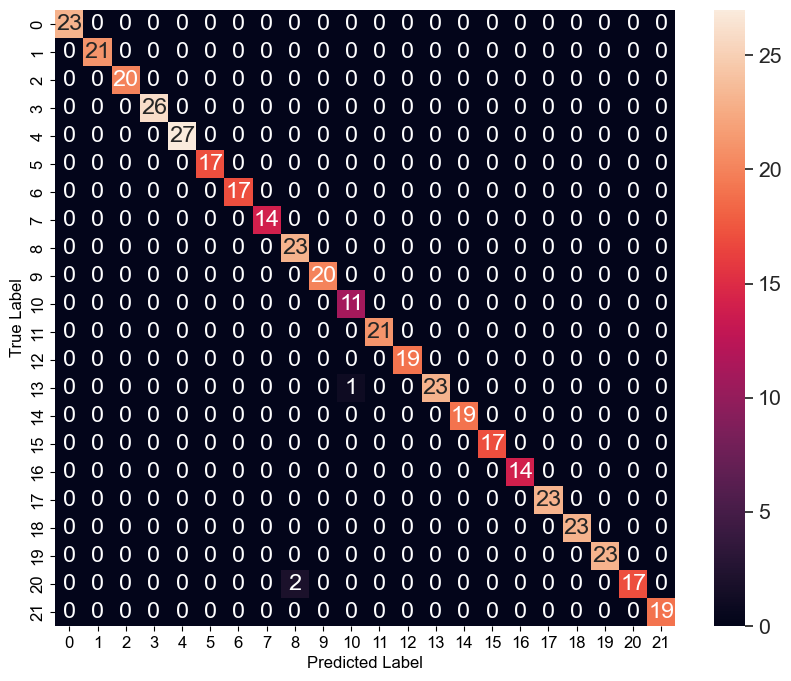

In [72]:
plot_confusion_matrix(y_test, y_preds_rf)

In [73]:
# Show classification report
print(classification_report(y_test, y_preds_rf))

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      1.00      0.96        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.92      1.00      0.96        11
       Maize       1.00      1.00      1.00        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      0.96      0.98        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1.00      1.00        14
      Papaya       1.00    

In [95]:
# Get feature importance scores
importance_scores = rf.feature_importances_

# Get feature names
feature_names = X_train.columns.tolist()

Text(0.5, 0, 'Feature Index')

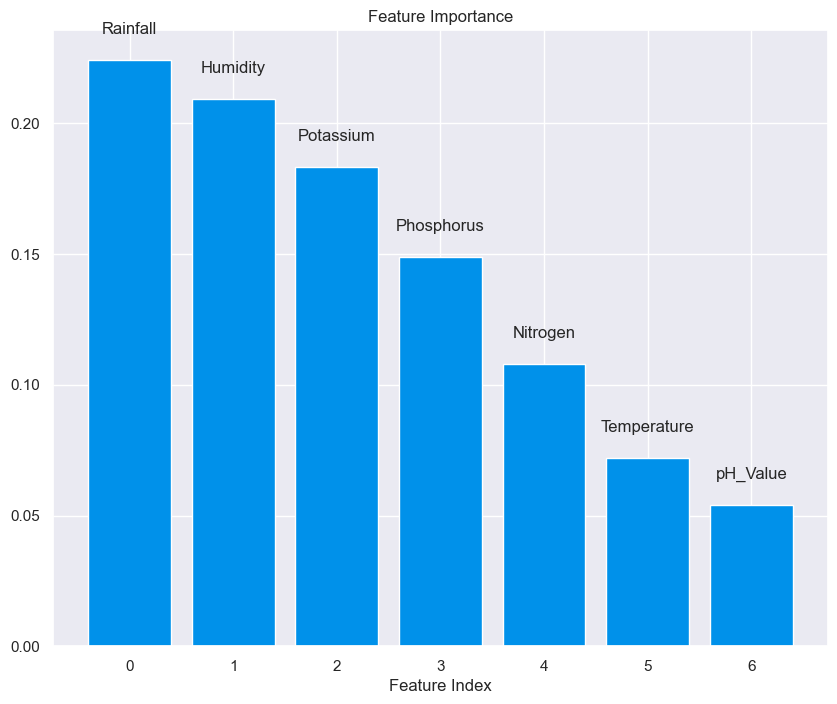

In [96]:
# Sort feature importance scores in descending order
sorted_idx = np.argsort(importance_scores)[::-1]

# Create plot
plt.figure(figsize=(10, 8))

# Plot feature importance scores
for i in range(len(importance_scores)):
    plt.bar(i, importance_scores[sorted_idx[i]], color='#0091ea', align='center')
    plt.text(i, 
             importance_scores[sorted_idx[i]]+0.01, 
             feature_names[sorted_idx[i]], 
             horizontalalignment='center')

# Add title and labels
plt.title('Feature Importance')
plt.xlabel('Feature Index')

<hr>

### Hypermeter Tuning with GridSearchCV

In [76]:
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30]
}

In [77]:
grid_search = GridSearchCV(
                            estimator=rf,
                            param_grid=param_grid,
                            scoring='accuracy',
                            cv=5,
                            verbose=True,
                            )

grid_search.fit(X_train, y_train)

print("Best parameters: ", grid_search.best_params_)
print("Accuracy score: ", grid_search.score(X_test, y_test))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best parameters:  {'max_depth': 20, 'n_estimators': 50}
Accuracy score:  0.9931818181818182


* No improvement of the original model with gridsearch

In [ ]:
# Get the best estimator
best_estimator = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_estimator.predict(X_test)

# Print the predictions
print("Predictions: ", y_pred)

<hr>

## Clustering

In [79]:
df_cluster = df.drop('Crop', axis=1)

In [80]:
# Not needed for this example since there are no categorical variables
df_cluster = pd.get_dummies(df_cluster, drop_first=True)
df_cluster.head(5)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


Text(0.5, 0, 'Number of Components')

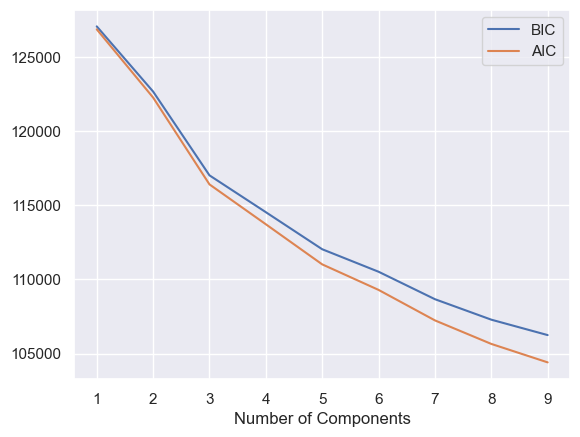

In [81]:
# Finding optimal number of clusters
from sklearn.mixture import GaussianMixture
# Prepare
n_components = np.arange(1,10)

# Create GMM model
models = [GaussianMixture(n_components= n,
                          random_state = 1502).fit(df_cluster) for n in n_components]

#Plot
plt.plot(n_components,
         [m.bic(df_cluster) for m in models],
         label = 'BIC')
plt.plot(n_components,
         [m.aic(df_cluster) for m in models],
         label = 'AIC')
plt.legend()
plt.xlabel('Number of Components')

In [82]:
# Gaussian Mixture Model
model = GaussianMixture(n_components= 4,
                        random_state = 1502).fit(df_cluster)

In [83]:
# Predict the cluster for each customer
cluster = pd.Series(model.predict(df_cluster))
cluster[:2]

0    1
1    1
dtype: int64

In [84]:
# Create Cluster variable
df_cluster['cluster'] = cluster
df_cluster.head(5)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,cluster
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


<hr>

### Visualizing the clustering

In [85]:
from sklearn.decomposition import PCA

In [86]:
data_pca = df_cluster.drop(['cluster'], axis=1)

3D Scatter of the data

In [87]:
#Initiating PCA to reduce dimentions aka features to 3
pca = PCA(n_components=3)
pca.fit(data_pca)
PCA_ds = pd.DataFrame(pca.transform(data_pca), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2200.0,-2.480440e-15,58.604247,-104.182669,-35.757181,-8.465669,10.306607,180.711278
col2,2200.0,7.441320e-15,54.157657,-84.309526,-44.703712,-10.190573,44.016507,170.783030
col3,2200.0,-4.134067e-15,36.728830,-67.731895,-30.630587,-7.256216,28.947581,81.762206


In [88]:
PCA_ds['Cluster'] = df_cluster['cluster']
PCA_ds

,col1,col2,col3,Cluster
0,-59.969729,84.055388,32.450240,1
1,-64.090628,107.779037,24.381552,1
2,-75.156888,142.468675,-0.556024,1
3,-80.247626,117.340628,13.940485,1
4,-85.084925,137.343003,16.712434,1
...,...,...,...,...
2195,-64.055404,54.019513,44.868290,1
2196,-52.816986,3.172884,38.516656,1
2197,-65.984590,48.821451,55.387287,1
2198,-42.988902,7.978078,55.117203,1


### 2D scatterplot of the data

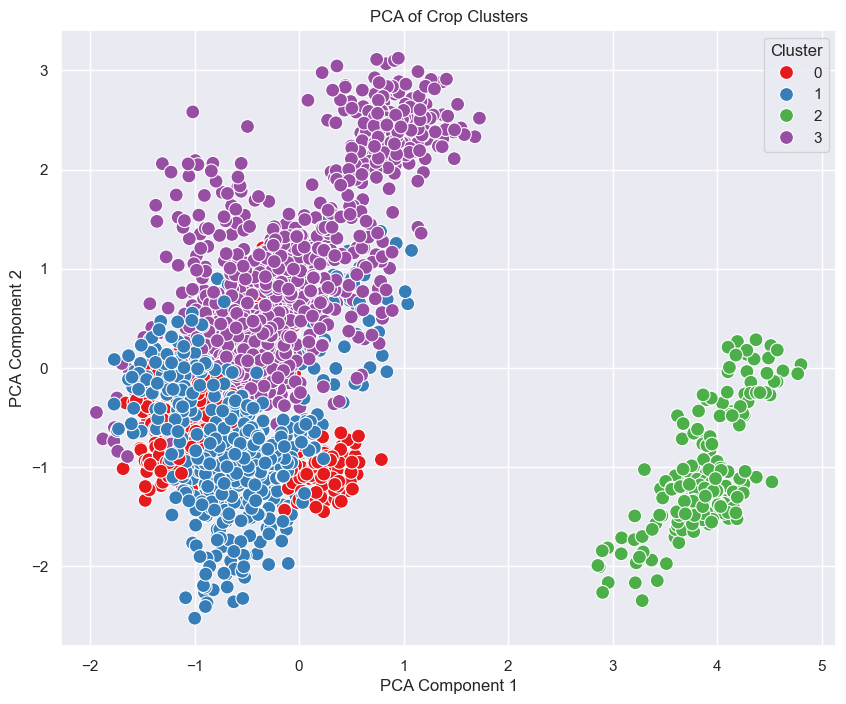

In [90]:
# Visualize the clusters using PCA
pca2 = PCA(n_components=2)
principal_components = pca2.fit_transform(X)
PCA_ds['PCA1'] = principal_components[:, 0]
PCA_ds['PCA2'] = principal_components[:, 1]

# Plot the PCA result
plt.figure(figsize=(10, 8))
sns.scatterplot(data=PCA_ds, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=100)
plt.title('PCA of Crop Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

<hr>

Once I have narrowed down the RandomForest model that I want to utilize: Streamline the process

Combined preprocessing and gridsearchcv in one process

In [91]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Does not apply to this dataset
# categorical_features = df.select_dtypes(exclude=['number']).columns
# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore"))
# ])


# Create a pipeline for numeric features
numeric_features = df.select_dtypes(include=['number']).columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ('scaler', StandardScaler())
])

# Create a preprocessor object
preprocessor = ColumnTransformer(
    transformers=[
        # ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ])

# Create a pipeline that includes the preprocessor and the model
model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("model", RandomForestClassifier())])

# Split the data
X = df.drop("Crop", axis=1)
y = df["Crop"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and score the model
model.fit(X_train, y_train)
model.score(X_test, y_test)
print('Baseline model:', model.score(X_test, y_test))

# Define the parameter grid
pipe_grid = {
    'model__n_estimators': [10, 50, 100, 200],
    'model__max_depth': [None, 10, 20, 30]
}

# Create a GridSearchCV object
gs_model = GridSearchCV(model, pipe_grid, cv=5, verbose=2, n_jobs=-1)
gs_model.fit(X_train, y_train)

print("Best parameters:", gs_model.best_params_)
print("Best score:", gs_model.best_score_)
# Fit the model with the entire training data using the best parameters
model.set_params(**gs_model.best_params_)
model.fit(X_train, y_train)
# Print the test score
print("Test score:", model.score(X_test, y_test))


Baseline model: 0.9931818181818182
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'model__max_depth': 30, 'model__n_estimators': 200}
Best score: 0.9960227272727273
Test score: 0.9931818181818182


In [ ]:
predictions = gs_model.best_estimator_.predict(X_test)
predictions